# Le Langage des Machines — Acte IV
## N-grammes : Capturer l'ordre des mots

Auteure : **Glorie M. WOWO** | Data Scientist / EdTech Entrepreneur

---

Dans les actes précédents, nous avons appris à :
- **Acte I** : Transformer du texte en vecteur (Bag of Words)
- **Acte II** : Pondérer les mots importants (TF-IDF)
- **Acte III** : Classifier les textes avec les probabilités (Naive Bayes)

Mais nous avons identifié une **limite majeure** : l'ordre des mots est perdu !

Dans cet acte, nous allons découvrir les **N-grammes**, une technique qui permet de capturer le contexte local des mots.

## 1. Le Problème : L'ordre des mots compte !

### 1.1 Rappel du problème

Avec Bag of Words et Naive Bayes, ces deux phrases sont **identiques** :

In [21]:
from sklearn.feature_extraction.text import CountVectorizer
import pandas as pd

# Deux phrases avec des sens OPPOSÉS
phrases = [
    "Ce cours est bon",
    "Ce cours n'est pas bon"
]

# Bag of Words classique (unigrams)
vectorizer_bow = CountVectorizer()
X_bow = vectorizer_bow.fit_transform(phrases)

# Affichage
df_bow = pd.DataFrame(
    X_bow.toarray(),
    columns=vectorizer_bow.get_feature_names_out(),
    index=['Positif: "Ce cours est bon"', 'Négatif: "Ce cours n\'est pas bon"']
)
print("=== Bag of Words (Unigrams) ===")
print(df_bow)
print("\n-- Les deux phrases contiennent 'bon' -> Naive Bayes les classera TOUTES DEUX positives !")

=== Bag of Words (Unigrams) ===
                                   bon  ce  cours  est  pas
Positif: "Ce cours est bon"          1   1      1    1    0
Négatif: "Ce cours n'est pas bon"    1   1      1    1    1

-- Les deux phrases contiennent 'bon' -> Naive Bayes les classera TOUTES DEUX positives !


### 1.2 Le cœur du problème

| Phrase | Contient "bon" | Contient "pas" | Sens réel |
|--------|---------------|----------------|----------|
| "Ce cours est bon" | ✅ | ❌ | Positif |
| "Ce cours n'est pas bon" | ✅ | ✅ | **Négatif** |

Le mot **"pas"** inverse le sens de **"bon"**, mais Bag of Words ne voit pas cette relation !

**Solution** : Au lieu de regarder les mots un par un, regardons des **séquences de mots**.

## 2. Les N-grammes : Définition

### 2.1 Qu'est-ce qu'un N-gramme ?

Un **N-gramme** est une séquence de N mots consécutifs.

| N | Nom | Exemple avec "Le cours est génial" |
|---|-----|-----------------------------------|
| 1 | **Unigram** | "le", "cours", "est", "génial" |
| 2 | **Bigram** | "le cours", "cours est", "est génial" |
| 3 | **Trigram** | "le cours est", "cours est génial" |

### 2.2 L'intuition

- **Unigram** = Bag of Words classique (ce qu'on faisait avant)
- **Bigram** = On capture les **paires de mots** -> "pas bon" devient UN token
- **Trigram** = On capture les **triplets** -> "n'est pas bon" devient UN token

In [3]:
# Visualisation des N-grammes
phrase = "Le cours est génial"

print(f"Phrase : \"{phrase}\"")
print("\n" + "="*50)

# Unigrams
vec_1 = CountVectorizer(ngram_range=(1, 1))
vec_1.fit([phrase])
print(f"\n1️ UNIGRAMS (N=1) : {list(vec_1.get_feature_names_out())}")

# Bigrams
vec_2 = CountVectorizer(ngram_range=(2, 2))
vec_2.fit([phrase])
print(f"\n2️ BIGRAMS (N=2)  : {list(vec_2.get_feature_names_out())}")

# Trigrams
vec_3 = CountVectorizer(ngram_range=(3, 3))
vec_3.fit([phrase])
print(f"\n3️ TRIGRAMS (N=3) : {list(vec_3.get_feature_names_out())}")

Phrase : "Le cours est génial"


1️ UNIGRAMS (N=1) : ['cours', 'est', 'génial', 'le']

2️ BIGRAMS (N=2)  : ['cours est', 'est génial', 'le cours']

3️ TRIGRAMS (N=3) : ['cours est génial', 'le cours est']


## 3. N-grammes en action : Résoudre le problème de la négation

### 3.1 Comparaison Unigrams vs Bigrams

In [4]:
phrases = [
    "Ce cours est bon",
    "Ce cours n'est pas bon"
]

# === UNIGRAMS ===
vec_uni = CountVectorizer(ngram_range=(1, 1))
X_uni = vec_uni.fit_transform(phrases)

print("=== UNIGRAMS (Bag of Words classique) ===")
df_uni = pd.DataFrame(X_uni.toarray(), 
                      columns=vec_uni.get_feature_names_out(),
                      index=['Positif', 'Négatif'])
print(df_uni)
print(f"\nVocabulaire : {len(vec_uni.get_feature_names_out())} tokens")
print("x 'bon' apparaît dans les DEUX phrases !")

=== UNIGRAMS (Bag of Words classique) ===
         bon  ce  cours  est  pas
Positif    1   1      1    1    0
Négatif    1   1      1    1    1

Vocabulaire : 5 tokens
x 'bon' apparaît dans les DEUX phrases !


In [5]:
# === BIGRAMS ===
vec_bi = CountVectorizer(ngram_range=(2, 2))
X_bi = vec_bi.fit_transform(phrases)

print("\n=== BIGRAMS ===")
df_bi = pd.DataFrame(X_bi.toarray(),
                     columns=vec_bi.get_feature_names_out(),
                     index=['Positif', 'Négatif'])
print(df_bi)
print(f"\nVocabulaire : {len(vec_bi.get_feature_names_out())} tokens")
print("--- 'est bon' vs 'pas bon' sont maintenant DISTINCTS !")


=== BIGRAMS ===
         ce cours  cours est  est bon  est pas  pas bon
Positif         1          1        1        0        0
Négatif         1          1        0        1        1

Vocabulaire : 5 tokens
--- 'est bon' vs 'pas bon' sont maintenant DISTINCTS !


In [6]:
# === UNIGRAMS + BIGRAMS (le plus courant) ===
vec_1_2 = CountVectorizer(ngram_range=(1, 2))
X_1_2 = vec_1_2.fit_transform(phrases)

print("\n=== UNIGRAMS + BIGRAMS (1,2) ===")
df_1_2 = pd.DataFrame(X_1_2.toarray(),
                      columns=vec_1_2.get_feature_names_out(),
                      index=['Positif', 'Négatif'])
print(df_1_2)
print(f"\nVocabulaire : {len(vec_1_2.get_feature_names_out())} tokens")
print("\n-- On a TOUS les mots individuels ET les paires !")


=== UNIGRAMS + BIGRAMS (1,2) ===
         bon  ce  ce cours  cours  cours est  est  est bon  est pas  pas  \
Positif    1   1         1      1          1    1        1        0    0   
Négatif    1   1         1      1          1    1        0        1    1   

         pas bon  
Positif        0  
Négatif        1  

Vocabulaire : 10 tokens

-- On a TOUS les mots individuels ET les paires !


### 3.2 Le token magique : "pas bon"

Regardons de plus près :

In [7]:
# Mise en évidence des tokens discriminants
print("=== Tokens discriminants ===")
print()
print('Phrase POSITIVE : "Ce cours est bon"')
print('  -> Contient : "est bon"  ')
print('  -> Ne contient PAS : "pas bon"')
print()
print('Phrase NÉGATIVE : "Ce cours n\'est pas bon"')
print('  -> Contient : "pas bon" ')
print('  -> Ne contient PAS : "est bon"')
print()
print("Avec les bigrams, 'pas bon' devient un SIGNAL NÉGATIF fort !")

=== Tokens discriminants ===

Phrase POSITIVE : "Ce cours est bon"
  -> Contient : "est bon"  
  -> Ne contient PAS : "pas bon"

Phrase NÉGATIVE : "Ce cours n'est pas bon"
  -> Contient : "pas bon" 
  -> Ne contient PAS : "est bon"

Avec les bigrams, 'pas bon' devient un SIGNAL NÉGATIF fort !


## 4. Application aux avis SUCCEED

Reprenons notre corpus d'avis de la plateforme SUCCEED :

In [8]:
# Corpus d'avis SUCCEED (avec négations !)
corpus = [
    "Le cours est génial",           # Positif
    "Formation super j'ai adoré",    # Positif  
    "Excellent je recommande",       # Positif
    "Le formateur est génial",       # Positif
    "Super formation très claire",   # Positif
    "C'était difficile à suivre",    # Négatif
    "Cours compliqué",               # Négatif
    "Ce n'est pas clair du tout",    # Négatif (avec négation !)
    "Je n'ai pas aimé ce cours",     # Négatif (avec négation !)
]

labels = [1, 1, 1, 1, 1, 0, 0, 0, 0]  # 1=positif, 0=négatif

print("=== Corpus SUCCEED ===")
for i, (avis, label) in enumerate(zip(corpus, labels)):
    sentiment = "✅ Positif" if label == 1 else "❌ Négatif"
    print(f"{i+1}. {sentiment} : \"{avis}\"")

=== Corpus SUCCEED ===
1. ✅ Positif : "Le cours est génial"
2. ✅ Positif : "Formation super j'ai adoré"
3. ✅ Positif : "Excellent je recommande"
4. ✅ Positif : "Le formateur est génial"
5. ✅ Positif : "Super formation très claire"
6. ❌ Négatif : "C'était difficile à suivre"
7. ❌ Négatif : "Cours compliqué"
8. ❌ Négatif : "Ce n'est pas clair du tout"
9. ❌ Négatif : "Je n'ai pas aimé ce cours"


In [20]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.model_selection import cross_val_score

# === Comparaison Unigrams vs Unigrams+Bigrams ===

# Modèle 1 : Unigrams seulement
vec_uni = CountVectorizer(ngram_range=(1, 1))
X_uni = vec_uni.fit_transform(corpus)
model_uni = MultinomialNB(alpha=1.0)
model_uni.fit(X_uni, labels)

# Modèle 2 : Unigrams + Bigrams
vec_bi = CountVectorizer(ngram_range=(1, 2))
X_bi = vec_bi.fit_transform(corpus)
model_bi = MultinomialNB(alpha=1.0)
model_bi.fit(X_bi, labels)

print("=== Taille du vocabulaire ===")
print(f"Unigrams seulement : {len(vec_uni.get_feature_names_out())} tokens")
print(f"Unigrams + Bigrams : {len(vec_bi.get_feature_names_out())} tokens")
print(f"\n-> Le vocabulaire est {len(vec_bi.get_feature_names_out()) / len(vec_uni.get_feature_names_out()):.1f}x plus grand avec les bigrams !")

=== Taille du vocabulaire ===
Unigrams seulement : 24 tokens
Unigrams + Bigrams : 50 tokens

-> Le vocabulaire est 2.1x plus grand avec les bigrams !


In [10]:
# Test sur des phrases avec négations
nouveaux_avis = [
    "Ce cours est bon",
    "Ce cours n'est pas bon",
    "Je n'ai pas aimé",
    "J'ai vraiment aimé",
    "Pas du tout clair",
    "Très clair et génial"
]

print("=== Prédictions ===")
print(f"{'Avis':<35} {'Unigrams':<12} {'Uni+Bigrams':<12}")
print("="*60)

for avis in nouveaux_avis:
    # Prédiction unigrams
    X_new_uni = vec_uni.transform([avis])
    pred_uni = model_uni.predict(X_new_uni)[0]
    label_uni = "✅ Positif" if pred_uni == 1 else "❌ Négatif"
    
    # Prédiction bigrams
    X_new_bi = vec_bi.transform([avis])
    pred_bi = model_bi.predict(X_new_bi)[0]
    label_bi = "✅ Positif" if pred_bi == 1 else "❌ Négatif"
    
    print(f'"{avis:<33}" {label_uni:<12} {label_bi:<12}')

=== Prédictions ===
Avis                                Unigrams     Uni+Bigrams 
"Ce cours est bon                 " ❌ Négatif    ❌ Négatif   
"Ce cours n'est pas bon           " ❌ Négatif    ❌ Négatif   
"Je n'ai pas aimé                 " ❌ Négatif    ❌ Négatif   
"J'ai vraiment aimé               " ❌ Négatif    ❌ Négatif   
"Pas du tout clair                " ❌ Négatif    ❌ Négatif   
"Très clair et génial             " ✅ Positif    ✅ Positif   


## 5. Le compromis : Contexte vs Sparsité

### 5.1 Plus de contexte = Plus de tokens

In [11]:
import matplotlib.pyplot as plt
import numpy as np

# Corpus plus large pour illustrer
corpus_large = corpus * 10  # On répète pour avoir plus de données

# Comparaison de la taille du vocabulaire
configs = [
    ((1, 1), "Unigrams"),
    ((1, 2), "Uni + Bigrams"),
    ((1, 3), "Uni + Bi + Trigrams"),
    ((2, 2), "Bigrams seuls"),
    ((2, 3), "Bi + Trigrams"),
]

print("=== Taille du vocabulaire selon la configuration ===")
print(f"{'Configuration':<25} {'Tokens':<10} {'Exemple'}")
print("="*70)

for ngram_range, name in configs:
    vec = CountVectorizer(ngram_range=ngram_range)
    vec.fit(corpus)
    tokens = vec.get_feature_names_out()
    exemple = tokens[0] if len(tokens) > 0 else ""
    print(f"{name:<25} {len(tokens):<10} \"{exemple}\"")

=== Taille du vocabulaire selon la configuration ===
Configuration             Tokens     Exemple
Unigrams                  24         "adoré"
Uni + Bigrams             50         "adoré"
Uni + Bi + Trigrams       68         "adoré"
Bigrams seuls             26         "ai adoré"
Bi + Trigrams             44         "ai adoré"


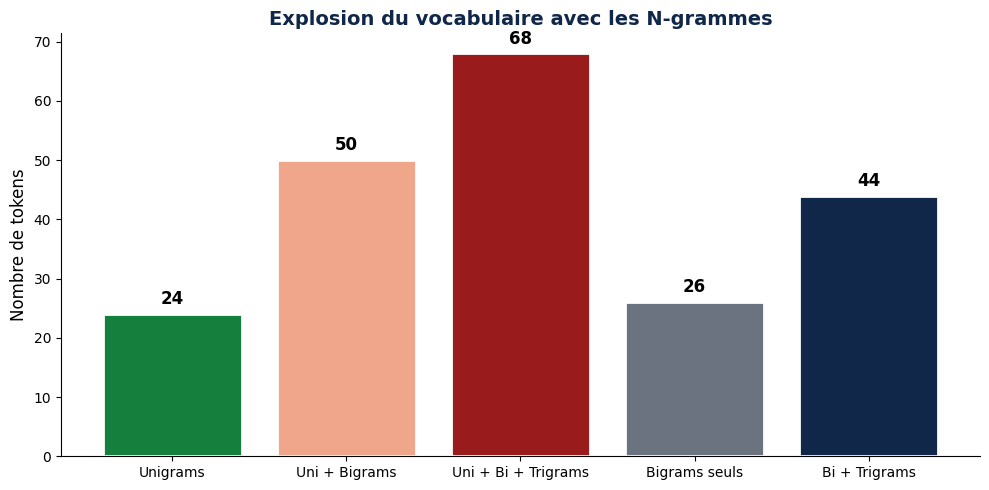


⚠️ Plus on augmente N, plus le vocabulaire explose !
-> Besoin de PLUS DE DONNÉES pour bien estimer les probabilités.


In [12]:
# Visualisation
fig, ax = plt.subplots(figsize=(10, 5))

names = [name for _, name in configs]
sizes = []
for ngram_range, _ in configs:
    vec = CountVectorizer(ngram_range=ngram_range)
    vec.fit(corpus)
    sizes.append(len(vec.get_feature_names_out()))

colors = ['#15803d', '#f0a68b', '#991b1b', '#6b7280', '#10274a']
bars = ax.bar(names, sizes, color=colors, edgecolor='white', linewidth=2)

# Annotations
for bar, size in zip(bars, sizes):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1, 
            str(size), ha='center', va='bottom', fontsize=12, fontweight='bold')

ax.set_ylabel('Nombre de tokens', fontsize=12)
ax.set_title('Explosion du vocabulaire avec les N-grammes', fontsize=14, fontweight='bold', color='#10274a')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('ngrams_vocab_size.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()

print("\n⚠️ Plus on augmente N, plus le vocabulaire explose !")
print("-> Besoin de PLUS DE DONNÉES pour bien estimer les probabilités.")

### 5.2 Le problème de la sparsité

Avec des N-grammes élevés, la matrice devient très **creuse** (sparse) :

In [13]:
# Calcul de la sparsité
print("=== Sparsité de la matrice ===")
print(f"{'Configuration':<25} {'Tokens':<10} {'Sparsité'}")
print("="*50)

for ngram_range, name in configs:
    vec = CountVectorizer(ngram_range=ngram_range)
    X = vec.fit_transform(corpus)
    
    # Sparsité = % de zéros
    total_elements = X.shape[0] * X.shape[1]
    non_zero = X.nnz
    sparsity = (1 - non_zero / total_elements) * 100
    
    print(f"{name:<25} {X.shape[1]:<10} {sparsity:.1f}% de zéros")

print("\n--- Plus la sparsité est élevée, plus il faut de données !")

=== Sparsité de la matrice ===
Configuration             Tokens     Sparsité
Unigrams                  24         83.3% de zéros
Uni + Bigrams             50         86.0% de zéros
Uni + Bi + Trigrams       68         86.8% de zéros
Bigrams seuls             26         88.5% de zéros
Bi + Trigrams             44         88.6% de zéros

--- Plus la sparsité est élevée, plus il faut de données !


## 6. Bonnes pratiques

### 6.1 Quelle configuration choisir ?

| Situation | Configuration recommandée |
|-----------|---------------------------|
| Peu de données (<1000 docs) | Unigrams seuls `(1,1)` |
| Données moyennes (1000-10000) | Unigrams + Bigrams `(1,2)` |
| Beaucoup de données (>10000) | Unigrams + Bigrams + Trigrams `(1,3)` |
| Détection de négations | Au minimum Bigrams `(1,2)` |

### 6.2 Limiter le vocabulaire

In [14]:
# Techniques pour limiter la taille du vocabulaire

# 1. Limiter le nombre maximum de features
vec_limited = CountVectorizer(
    ngram_range=(1, 2),
    max_features=100  # Garder les 100 tokens les plus fréquents
)

# 2. Ignorer les tokens trop rares ou trop fréquents
vec_filtered = CountVectorizer(
    ngram_range=(1, 2),
    min_df=2,    # Apparaît dans au moins 2 documents
    max_df=0.95  # Apparaît dans max 95% des documents
)

# 3. Combiner avec TF-IDF
from sklearn.feature_extraction.text import TfidfVectorizer

vec_tfidf = TfidfVectorizer(
    ngram_range=(1, 2),
    max_features=100
)

print("=== Techniques de réduction du vocabulaire ===")
print("1. max_features=100 -> Garde les 100 tokens les plus fréquents")
print("2. min_df=2 -> Ignore les tokens qui apparaissent dans moins de 2 docs")
print("3. max_df=0.95 -> Ignore les tokens présents dans plus de 95% des docs")
print("4. TF-IDF -> Pondère automatiquement pour réduire l'impact des mots communs")

=== Techniques de réduction du vocabulaire ===
1. max_features=100 -> Garde les 100 tokens les plus fréquents
2. min_df=2 -> Ignore les tokens qui apparaissent dans moins de 2 docs
3. max_df=0.95 -> Ignore les tokens présents dans plus de 95% des docs
4. TF-IDF -> Pondère automatiquement pour réduire l'impact des mots communs


## 7. Code complet : Pipeline avec N-grammes

In [15]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.pipeline import Pipeline

# === Pipeline complet ===
pipeline = Pipeline([
    ('vectorizer', TfidfVectorizer(
        ngram_range=(1, 2),    # Unigrams + Bigrams
        max_features=1000,     # Limiter le vocabulaire
        min_df=1,              # Minimum 1 document
    )),
    ('classifier', MultinomialNB(alpha=1.0))  # Lissage de Laplace
])

# Entraînement
pipeline.fit(corpus, labels)

# Test
test_avis = [
    "Ce cours est vraiment génial",
    "Ce n'est pas du tout clair",
    "J'ai adoré cette formation",
    "Je n'ai pas compris",
    "Excellent formateur",
    "Pas terrible ce cours"
]

print("=== Prédictions avec le pipeline N-grammes + TF-IDF + Naive Bayes ===")
print()

for avis in test_avis:
    pred = pipeline.predict([avis])[0]
    proba = pipeline.predict_proba([avis])[0]
    
    sentiment = "✅ Positif" if pred == 1 else "❌ Négatif"
    confiance = max(proba) * 100
    
    print(f'"{avis}"')
    print(f'  -> {sentiment} (confiance: {confiance:.0f}%)')
    print()

=== Prédictions avec le pipeline N-grammes + TF-IDF + Naive Bayes ===

"Ce cours est vraiment génial"
  -> ✅ Positif (confiance: 56%)

"Ce n'est pas du tout clair"
  -> ❌ Négatif (confiance: 66%)

"J'ai adoré cette formation"
  -> ✅ Positif (confiance: 68%)

"Je n'ai pas compris"
  -> ❌ Négatif (confiance: 56%)

"Excellent formateur"
  -> ✅ Positif (confiance: 67%)

"Pas terrible ce cours"
  -> ❌ Négatif (confiance: 63%)



## 8. Visualisation : Tokens les plus importants

Pour cela, nous allons utiliser le logratio
**Interprétation du log-ratio des tokens**

Le log-ratio indique **à quel point un token est plus probable dans les avis positifs que dans les avis négatifs (ou l’inverse)**.  
Il s’agit donc, au départ, d’une **comparaison de probabilités entre deux classes**, et non simplement d’un comptage brut.

Plus précisément, le **log-ratio mesure à quel point un mot ou un n-gram est caractéristique d’une classe par rapport à l’autre**.  
Un score élevé signifie que le token apparaît **beaucoup plus fréquemment** dans les avis positifs que dans les avis négatifs (ou inversement).

L’utilisation du **logarithme** présente deux avantages majeurs :
- elle permet une **comparaison symétrique** entre les classes ;
- elle évite que des **tokens rares mais exclusifs** dominent la visualisation.

---

**Formule du log-ratio**

$$
\text{log-ratio}(token) = \log\left(\frac{P(token \mid positif)}{P(token \mid négatif)}\right)
$$

---

**Interprétation des valeurs**

- **log-ratio > 0** -> token associé aux avis **positifs**
- **log-ratio < 0** -> token associé aux avis **négatifs**
- **log-ratio = 0** ->  token **neutre**

Une propriété essentielle du logarithme est :

$$
\log\left(\frac{a}{b}\right) = -\log\left(\frac{b}{a}\right)
$$

Cette symétrie rend le log-ratio **idéal pour visualiser l’opposition positif vs négatif de manière équilibrée**.


In [16]:
import numpy as np

# Extraire les composants du pipeline
vectorizer = pipeline.named_steps['vectorizer']
classifier = pipeline.named_steps['classifier']

# Noms des features
feature_names = vectorizer.get_feature_names_out()

# Log-probabilités par classe
log_probs = classifier.feature_log_prob_

# Différence entre positif et négatif
diff = log_probs[1] - log_probs[0]  # positif - négatif

# Top tokens positifs et négatifs
top_positive_idx = np.argsort(diff)[-10:][::-1]
top_negative_idx = np.argsort(diff)[:10]

print("=== Tokens les plus discriminants ===")
print("\n🟢 SIGNAL POSITIF (tokens associés aux avis positifs) :")
for idx in top_positive_idx:
    print(f"  • {feature_names[idx]}")

print("\n🔴 SIGNAL NÉGATIF (tokens associés aux avis négatifs) :")
for idx in top_negative_idx:
    print(f"  • {feature_names[idx]}")

=== Tokens les plus discriminants ===

🟢 SIGNAL POSITIF (tokens associés aux avis positifs) :
  • le
  • génial
  • est génial
  • formation
  • super
  • je recommande
  • excellent je
  • recommande
  • excellent
  • le cours

🔴 SIGNAL NÉGATIF (tokens associés aux avis négatifs) :
  • compliqué
  • cours compliqué
  • ce
  • pas
  • difficile suivre
  • était difficile
  • suivre
  • difficile
  • était
  • aimé ce


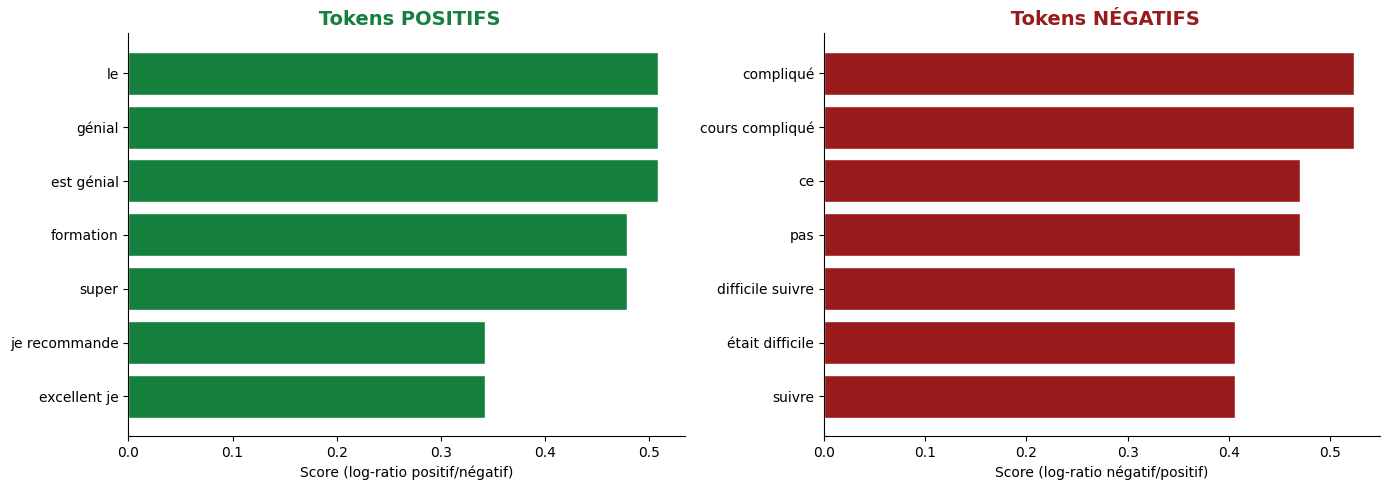


-- Les bigrams comme 'pas clair' ou 'ai adoré' sont très discriminants !


In [18]:
# Visualisation des tokens discriminants
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Tokens positifs
ax1 = axes[0]
tokens_pos = [feature_names[i] for i in top_positive_idx[:7]]
scores_pos = [diff[i] for i in top_positive_idx[:7]]
ax1.barh(tokens_pos[::-1], scores_pos[::-1], color='#15803d', edgecolor='white')
ax1.set_xlabel('Score (log-ratio positif/négatif)')
ax1.set_title(' Tokens POSITIFS', fontsize=14, fontweight='bold', color='#15803d')
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)

# Tokens négatifs
ax2 = axes[1]
tokens_neg = [feature_names[i] for i in top_negative_idx[:7]]
scores_neg = [abs(diff[i]) for i in top_negative_idx[:7]]
ax2.barh(tokens_neg[::-1], scores_neg[::-1], color='#991b1b', edgecolor='white')
ax2.set_xlabel('Score (log-ratio négatif/positif)')
ax2.set_title(' Tokens NÉGATIFS', fontsize=14, fontweight='bold', color='#991b1b')
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('ngrams_tokens_discriminants.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()

print("\n-- Les bigrams comme 'pas clair' ou 'ai adoré' sont très discriminants !")

## 9. Récapitulatif

### Ce que nous avons appris

| Concept | Description |
|---------|-------------|
| **N-gramme** | Séquence de N mots consécutifs |
| **Unigram** | 1 mot (= Bag of Words classique) |
| **Bigram** | 2 mots consécutifs (ex: "pas bon") |
| **Trigram** | 3 mots consécutifs (ex: "n'est pas bon") |

### Forces des N-grammes
- ✅ Capture le **contexte local** (négations, expressions)
- ✅ "pas bon" ≠ "bon"
- ✅ Améliore la classification de sentiments

### Limites des N-grammes
- ❌ **Explosion du vocabulaire** (plus de tokens)
- ❌ **Sparsité** (matrices creuses)
- ❌ Besoin de **plus de données**
- ❌ Ne capture pas la **sémantique** ("bon" ≠ "excellent" pour le modèle)

### La série jusqu'ici

| Acte | Technique | Ce qu'on apprend |
|------|-----------|------------------|
| I | Bag of Words | Transformer texte -> vecteur |
| II | TF-IDF | Pondérer les mots importants |
| III | Naive Bayes | Classifier avec les probabilités |
| **IV** | **N-grammes** | **Capturer l'ordre des mots** |
| V | Word Embeddings | Comprendre la sémantique (à venir) |

## 10. Prochaine étape : Acte V — Word Embeddings

Les N-grammes capturent l'ordre local, mais pas la **sémantique**.

Pour le modèle actuel :
- "excellent" et "génial" sont des tokens **complètement différents**
- "roi" et "reine" n'ont **aucune relation**

Dans l'Acte V, nous découvrirons les **Word Embeddings** (Word2Vec, GloVe) qui représentent les mots dans un espace où les mots similaires sont proches !

$$\text{roi} - \text{homme} + \text{femme} \approx \text{reine}$$

---



**Glorie M. WOWO** | Data Scientist / EdTech Entrepreneur